# Cloud opacities tutorial
This tutorial shows how to create cloud opacity objects and compute their extinction coefficient spectra for a given atmospheric profile.

<div class="alert alert-info">

Note

You can also find this tutorial as a [jupyter notebook here](https://github.com/pcubillos/pyratbay/blob/master/docs/cookbooks/opacity_aerosols.ipynb).

</div>

In [1]:
# Lets start by importing some useful modules
import pyratbay.atmosphere as pa
import pyratbay.spectrum as ps
import pyratbay.opacity as op

import matplotlib.pyplot as plt
import matplotlib
import numpy as np

---------------------------------------------------------------------

# 1. Lecavelier (Rayleigh-like) model

In [2]:

# We will sample the opacity over a constant-resolution wavelength array
# (boundaries in micron units)
wl_min = 0.2
wl_max = 6.0
resolution = 15000.0
wl = ps.constant_resolution_spectrum(wl_min, wl_max, resolution)

# Atmospheric pressure profile in bars:
nlayers = 81
pressure = pa.pressure('1e-8 bar', '1e2 bar', nlayers)

# Parametric model based on Lecavelier des Etangs (2008) model for H2:
lecavelier = op.clouds.Lecavelier(pressure, wl=wl)

print(lecavelier)

Model name (name): 'lecavelier'
Pressure array (pressure, bar): 1e-08 ... 100.0
Number of model parameters (npars): 2
Parameter name     Value
  (pnames)         (pars)
  log_k_ray         0.000e+00
  alpha_ray        -4.000e+00
Wavenumber (wn, cm-1):
   [50000.00 49996.67 49993.33 ... 1667.00 1666.88 1666.77]
Cross section (cross_section, cm2 molec-1):
   [ 4.980e-26  4.979e-26  4.978e-26 ...  6.153e-32  6.152e-32  6.150e-32]



The ``Lecavelier()`` model implements a power-law cross section (i.e., non-gray) with two parameters that set the strength ($\log\kappa_{\rm ray}$) and slope ($\alpha_{\rm ray}$) of the absorption:
$$
k(\lambda) = \kappa_{\rm ray}\ \kappa_0 \left(\frac{\lambda}{\lambda_0}\right)^{\alpha_{\rm ray}}
$$
with constants $\lambda_0=0.35$ um and $\kappa_0=5.31 \times 10^{-27}$ cm<sup>2</sup> molecule<sup>-1</sup>.

Text(0.5, 1.0, 'Parametric Rayleigh opacity at 1mbar')

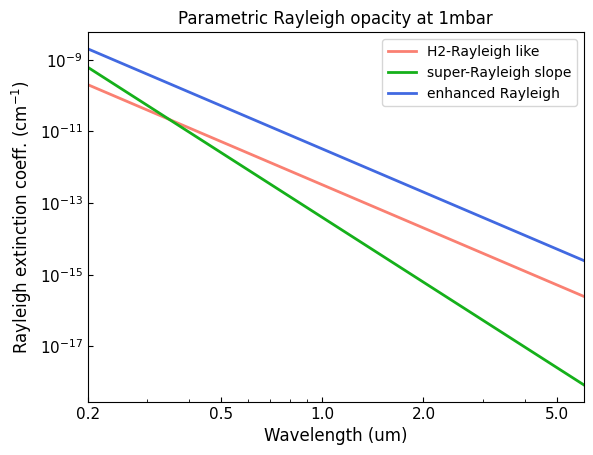

In [3]:
# Evaluate extinction coefficients
temperature = np.tile(1800.0, nlayers)
# log_kappa_ray = 0.0 and alpha_ray = -4 reproduces H2-Rayleigh opacity
rayleigh_ec = lecavelier.calc_extinction_coefficient(
    temperature, pars=[0.0, -4.0],
)

# A super-Rayleigh slope
super_ray_ec = lecavelier.calc_extinction_coefficient(
    temperature,
    pars=[0.0, -6.0],
)

# Enhanced Rayleigh-like absorption
enhanced_ray_ec = lecavelier.calc_extinction_coefficient(
    temperature,
    pars=[1.0, -4.0],
)


plt.figure(2)
plt.clf()
ax = plt.subplot(111)
ax.plot(wl, rayleigh_ec[40], color='salmon', lw=2.0, label='H2-Rayleigh like')
ax.plot(wl, super_ray_ec[40], color='xkcd:green', lw=2.0, label='super-Rayleigh slope')
ax.plot(wl, enhanced_ray_ec[40], color='royalblue', lw=2.0, label='enhanced Rayleigh')
ax.set_xscale('log')
ax.set_yscale('log')
ax.xaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.set_xticks([0.2, 0.5, 1.0, 2.0, 5.0])
ax.tick_params(which='both', direction='in', labelsize=11)
ax.set_xlim(np.amin(wl), np.amax(wl))
ax.set_xlabel('Wavelength (um)', fontsize=12)
ax.set_ylabel('Rayleigh extinction coeff. (cm$^{-1}$)', fontsize=12)
ax.legend(loc='upper right')
ax.set_title('Parametric Rayleigh opacity at 1mbar')


Compute chemical abundances.


Text(0.5, 1.0, 'Parametric Rayleigh opacity at 1mbar')

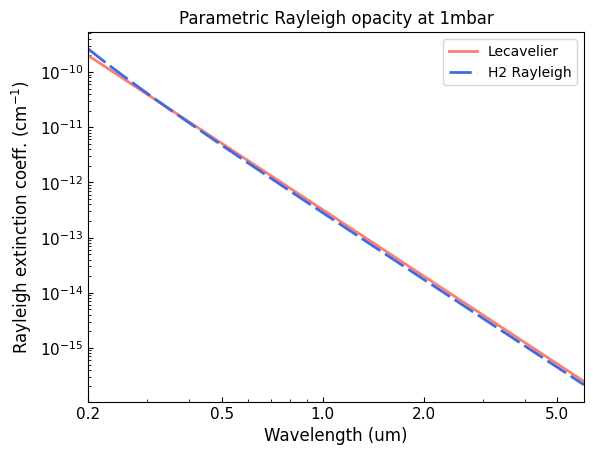

In [4]:
# Get VMRs in thermochemical equilibrium for a simple mix of species
# and their number-density profiles under IGL (molecules per cm3)
species = ['H2', 'H', 'He']
net, specs, vmr = pa.chemistry('equilibrium', pressure, temperature, species)
number_densities = pa.ideal_gas_density(vmr, pressure, temperature)

H2_density = number_densities[:,0]

# Compare to H2 absorption
H2_rayleigh = op.rayleigh.Kurucz(wn=1e4/wl, species='H2')
H2_ec = H2_rayleigh.calc_extinction_coefficient(H2_density)

# See results:
plt.figure(2)
plt.clf()
ax = plt.subplot(111)
ax.plot(wl, rayleigh_ec[40], color='salmon', lw=2.0, label='Lecavelier')
ax.plot(wl, H2_ec[40], color='royalblue', lw=2.0, dashes=(8,2), label='H2 Rayleigh')
ax.set_xscale('log')
ax.set_yscale('log')
ax.xaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.set_xticks([0.2, 0.5, 1.0, 2.0, 5.0])
ax.tick_params(which='both', direction='in', labelsize=11)
ax.set_xlim(np.amin(wl), np.amax(wl))
ax.set_xlabel('Wavelength (um)', fontsize=12)
ax.set_ylabel('Rayleigh extinction coeff. (cm$^{-1}$)', fontsize=12)
ax.legend(loc='upper right')
ax.set_title('Parametric Rayleigh opacity at 1mbar')
